In [3]:
#install kaggle
!pip install -q kaggle



In [4]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"triptitak","key":"906bd9e1c254a253d1f608fbce624d9f"}'}

In [5]:
#create a kaggle folder
!mkdir -p ~/.kaggle

# ceate the kaggle.json to folder created

!cp kaggle.json ~/.kaggle/

In [6]:
#permission for the json to act
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# to list all dataset in kaggle
!kaggle datasets list

ref                                                          title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
dmahajanbe23/bmw-global-automotive-sales                     BMW Global Automotive Sales                             55017  2026-02-22 18:18:38.170000           3176         58  1.0              
shree0910/online-vs-in-store-shopping-behaviour-dataset      Online vs In-Store Shopping Behaviour Dataset          354896  2026-02-18 08:16:20.137000           1748         39  1.0              
krupalpatel07/gold-price-dynamics                            Gold Price Dynamics                                     85982  2026-03-03 05:42:46.960000            579         23  1.0              
likithagedipudi/star

In [7]:
!kaggle datasets download -d faysalmiah1721758/potato-dataset

Dataset URL: https://www.kaggle.com/datasets/faysalmiah1721758/potato-dataset
License(s): CC0-1.0
  0% 0.00/37.8M [00:00<?, ?B/s]
100% 37.8M/37.8M [00:00<00:00, 1.48GB/s]


In [8]:
import zipfile
zip_ref = zipfile.ZipFile('/content/potato-dataset.zip', 'r')
zip_ref.extractall("/content")
zip_ref.close()

In [9]:
!ls

kaggle.json  potato-dataset.zip  PotatoDisease	sample_data


In [10]:
#impoting libraries
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
import tensorflow as tf
from tensorflow import keras


In [11]:
DATADIR = '/content/PotatoDisease'  #base directory
CATAGORIES = ['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

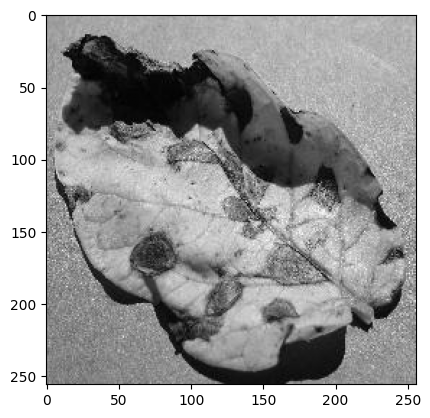

In [12]:
for category in CATAGORIES:
  path = os.path.join(DATADIR, category)  #constructing the path
  for img in os.listdir(path):
    img_array = cv2.imread(os.path.join(path, img),cv2.IMREAD_GRAYSCALE)
    plt.imshow(img_array, cmap='gray')
    plt.show()
    break
  break

array([[151, 154, 156, ..., 177, 177, 184],
       [151, 154, 156, ..., 179, 181, 189],
       [152, 155, 158, ..., 179, 181, 187],
       ...,
       [124, 123, 129, ..., 144, 150, 146],
       [125, 125, 138, ..., 134, 147, 152],
       [115, 119, 166, ..., 142, 143, 142]], dtype=uint8)
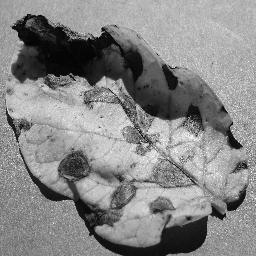

In [13]:
img_array

In [14]:
img_array.shape

(256, 256)

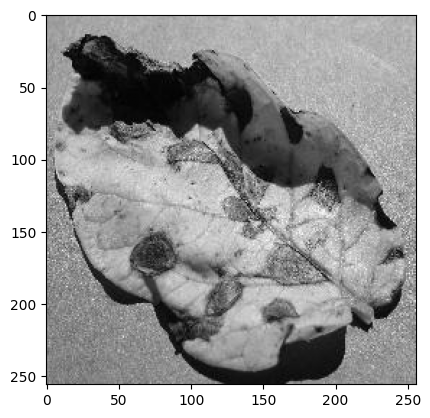

In [15]:
IMG_SIZE = 256
new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
plt.imshow(new_array, cmap='gray')
plt.show()

In [16]:
# CREATING TRANING DATA
training_data = []

def create_training_data():
  for category in CATAGORIES:
   path = os.path.join(DATADIR, category)
   class_num = CATAGORIES.index(category)
   for img in os.listdir(path):
    try:
     img_array = cv2.imread(os.path.join(path, img),cv2.IMREAD_GRAYSCALE)
     new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
     training_data.append([new_array, class_num])
    except Exception as e:
      pass

In [17]:
create_training_data()

In [18]:
len(training_data)

2152

In [19]:
import random
random.shuffle(training_data)

In [20]:
X=[]
Y=[]

for features, label in training_data:
  X.append(features)
  Y.append(label)

In [21]:
type(X),type(Y)

(list, list)

In [22]:
x = np.array(X).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
y = np.array(Y)

In [23]:
type(x),type(y)

(numpy.ndarray, numpy.ndarray)

In [24]:
x = x/255

In [25]:
x.shape

(2152, 256, 256, 1)

In [26]:
#building CNN Model

model = keras.Sequential([

    #CONVOLUTION LAYAR 1
    keras.layers.Conv2D(64, kernel_size=(3,3), input_shape =x.shape[1:], activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2,2)),

    #CONVOLUTION LAYAR 2
    keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2,2)),

    #FLATTENING LAYAR
    keras.layers.Flatten(),

    #HIDDEN LAYAR 1
    keras.layers.Dense(64, activation='relu'),

    #OUTPUT LAYAR
    keras.layers.Dense(3, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x,y, batch_size = 32, epochs=5, validation_split = 0.1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
61/61 ━━━━━━━━━━━━━━━━━━━━ 311s 5s/step - accuracy: 0.5570 - loss: 1.6491 - val_accuracy: 0.8611 - val_loss: 0.4333
Epoch 2/5
61/61 ━━━━━━━━━━━━━━━━━━━━ 313s 5s/step - accuracy: 0.8727 - loss: 0.3642 - val_accuracy: 0.8426 - val_loss: 0.3825
Epoch 3/5
61/61 ━━━━━━━━━━━━━━━━━━━━ 310s 5s/step - accuracy: 0.9101 - loss: 0.2263 - val_accuracy: 0.8981 - val_loss: 0.2544
Epoch 4/5
61/61 ━━━━━━━━━━━━━━━━━━━━ 309s 5s/step - accuracy: 0.9524 - loss: 0.1419 - val_accuracy: 0.9074 - val_loss: 0.2976
Epoch 5/5
61/61 ━━━━━━━━━━━━━━━━━━━━ 325s 5s/step - accuracy: 0.9836 - loss: 0.0634 - val_accuracy: 0.9028 - val_loss: 0.2742
